# Assignment 3 - Python Visualization

**Dataset:** Comparative Birth, Death, Marriage data, Ontario Data Catalogue.

This notebook downloads the official raw CSV, saves a local copy, derives the plotting table in code, and saves the final PNG with Matplotlib. No manually prepared annual summary is used.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

DATA_URL = "https://data.ontario.ca/dataset/7d6d02f8-140f-467d-a7c1-861480cadb6d/resource/8f40d667-b379-41c6-b929-cdcce6e0ada7/download/comparative_birth_death_marriage_data_1925-2025.csv"

# Use the assignment folder when the notebook is run from the parent directory.
ROOT = Path.cwd()
if ROOT.name != "assignment_3" and (ROOT / "assignment_3").exists():
    ROOT = ROOT / "assignment_3"

DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs"
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Save the raw downloaded file so the source data is kept with the assignment.
raw_path = DATA_DIR / "comparative_birth_death_marriage_data_1925-2025.csv"
df = pd.read_csv(DATA_URL)
df.to_csv(raw_path, index=False)
df.head()


,Year/Année,Live Births/Naissances vivantes,Marriages/Mariages,Deaths/Dècés
0,1925,70122,33960,23074
1,1926,67617,35909,23632
2,1927,67671,34775,24677
3,1928,68510,37128,25728
4,1929,68458,38123,27605


In [2]:
# Match columns by keyword so the code works with the bilingual column names.
def find_col(keyword):
    matches = [col for col in df.columns if keyword.lower() in col.lower()]
    if not matches:
        raise ValueError(f"No column contains: {keyword}")
    return matches[0]

year_col = find_col("Year")
birth_col = find_col("Live Births")
death_col = find_col("Deaths")
marriage_col = find_col("Marriages")

clean = df[[year_col, birth_col, death_col, marriage_col]].copy()
clean.columns = ["year", "live_births", "deaths", "marriages"]

# Convert any comma-formatted counts to numeric values before plotting.
for col in ["live_births", "deaths", "marriages"]:
    clean[col] = pd.to_numeric(clean[col].astype(str).str.replace(",", "", regex=False), errors="coerce")
clean["year"] = pd.to_numeric(clean["year"], errors="coerce")
clean = clean.dropna(subset=["year", "live_births", "deaths", "marriages"]).copy()
clean["year"] = clean["year"].astype(int)

# 2024 and 2025 are excluded because the Ontario catalogue labels them
# preliminary and says 2023 is the most current published annual report year.
# Keeping only finalized years avoids mixing complete annual counts with
# provisional quarterly/cumulative counts.
plot_data = clean[clean["year"].between(1994, 2023)].sort_values("year").copy()

print(f"Rows plotted: {len(plot_data)}")
print(f"Year range shown: {plot_data['year'].min()}-{plot_data['year'].max()}")
plot_data.tail()


Rows plotted: 30
Year range shown: 1994-2023


,year,live_births,deaths,marriages
94,2019,142384,107865,62539
95,2020,138383,116071,40628
96,2021,142754,117662,53150
97,2022,137450,126105,69012
98,2023,139707,121822,68994


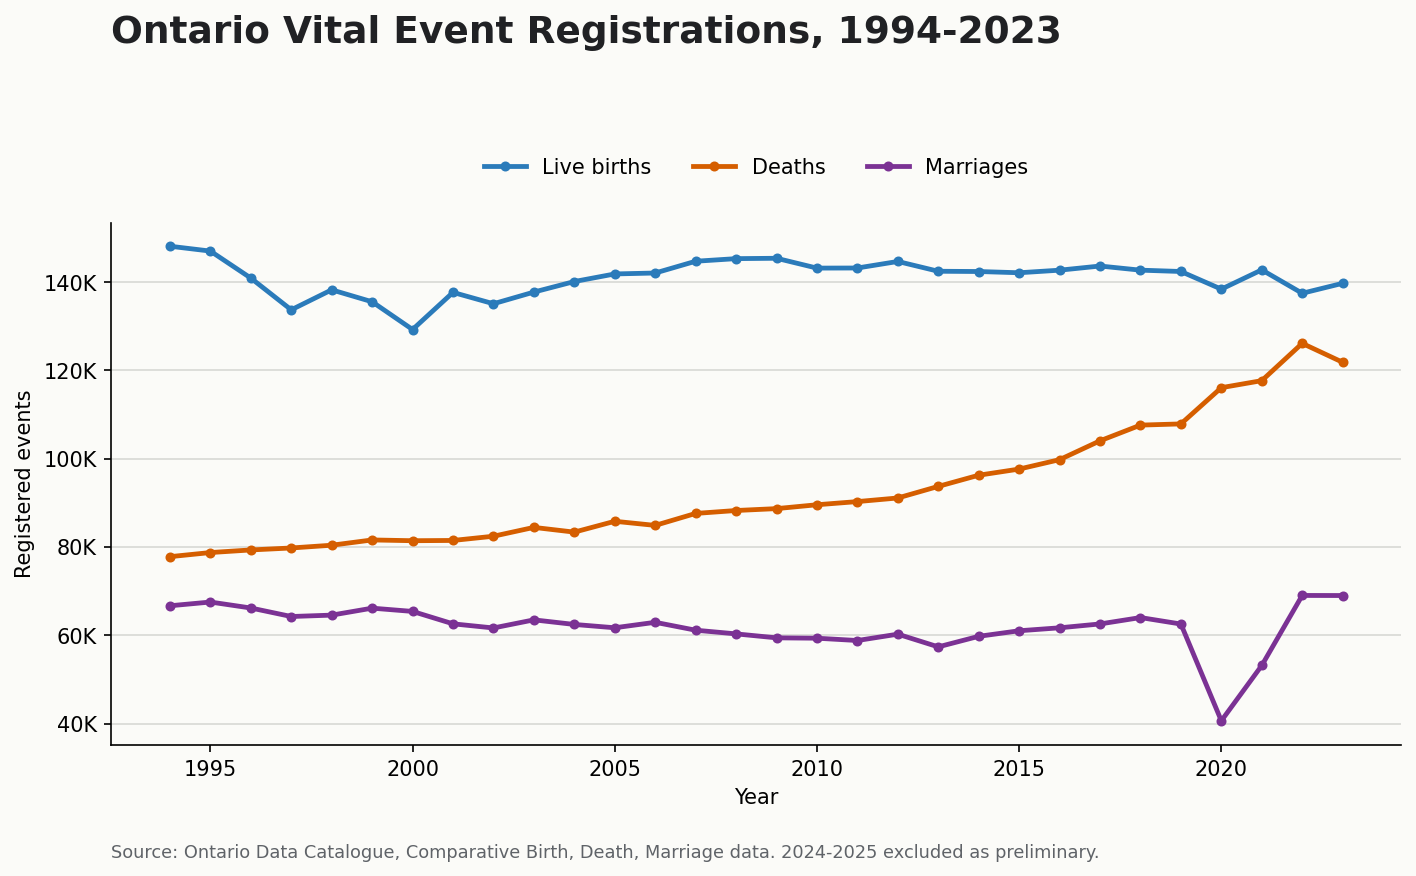

Saved: /Users/farazparnia/Desktop/DSI_Assignments/visualization/02_activities/assignments/assignment_3/outputs/visualization_1_python_1994_2023_trends.png


In [3]:
output_file = OUTPUT_DIR / "visualization_1_python_1994_2023_trends.png"

colors = {
    "Live births": "#2b7bba",
    "Deaths": "#d55e00",
    "Marriages": "#7b3294",
}

# Plot each year as a small dot so the annual values are visible along the lines.
plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor("#fbfbf8")
ax.set_facecolor("#fbfbf8")

ax.plot(plot_data["year"], plot_data["live_births"], marker="o", markersize=3.8, color=colors["Live births"], linewidth=2.3, label="Live births")
ax.plot(plot_data["year"], plot_data["deaths"], marker="o", markersize=3.8, color=colors["Deaths"], linewidth=2.3, label="Deaths")
ax.plot(plot_data["year"], plot_data["marriages"], marker="o", markersize=3.8, color=colors["Marriages"], linewidth=2.3, label="Marriages")

fig.text(0.10, 0.94, "Ontario Vital Event Registrations, 1994-2023", fontsize=18, weight="bold", color="#202124")

ax.set_xlabel("Year")
ax.set_ylabel("Registered events")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value/1000:.0f}K"))
ax.grid(axis="y", color="#d7d9d4", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.05), ncol=3)

fig.text(0.10, 0.035, "Source: Ontario Data Catalogue, Comparative Birth, Death, Marriage data. 2024-2025 excluded as preliminary.", fontsize=8.5, color="#5f6368", ha="left")
fig.subplots_adjust(left=0.10, right=0.96, top=0.74, bottom=0.16)
fig.savefig(output_file, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"Saved: {output_file}")
